# MoCap Analysis — Transform to TFrame Coordinate System

**Workflow:**
- `multiple_rigid_body.py` is loaded once via `importlib`.
- It runs its `__main__` block which produces `rb_dfs` and `st_time`.
- This notebook uses those DataFrames directly — no CSV re-read.

**Pipeline:**
1. Imports
2. Load script → get `rb_dfs` and `st_time`
3. Verify DataFrames are ready
4. Inspect raw data
5. Define and run coordinate frame transform
6. Sanity checks
7. Print noark m5 position in tframe (metres)
8. Print table m1–m5 positions in tframe (metres)


## Cell 1 — Imports

In [6]:
import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R

print('Libraries loaded OK')

Libraries loaded OK


## Cell 2 — Load `multiple_rigid_body.py`

Walks up from the notebook directory to find the repo root,
then loads the script via `importlib`. The script's `__main__` block
runs automatically and populates `rb_dfs` and `st_time` into this
notebook's namespace.

In [7]:
import sys, importlib.util
from pathlib import Path

# ── locate this notebook's directory ─────────────────────────────────────────
try:
    _nb_file = Path(globals()['__vsc_ipynb_file__']).resolve()
    _nb_dir  = _nb_file.parent
except KeyError:
    _nb_dir = Path.cwd()

# ── walk up to find repo root ─────────────────────────────────────────────────
repo_root = _nb_dir
for candidate in [_nb_dir, *_nb_dir.parents]:
    if (candidate / 'vaideesh').exists() or (candidate / '.venv').exists():
        repo_root = candidate
        break

print(f'Repo root : {repo_root}')

# ── add script directory to sys.path so local imports inside the module work ──
_script_path = repo_root / 'vaideesh' / 'Analysis' / 'multiple_rigid_body.py'
assert _script_path.exists(), f'Script not found: {_script_path}'

_script_dir = str(_script_path.parent)
if _script_dir not in sys.path:
    sys.path.insert(0, _script_dir)

# ── load the module ───────────────────────────────────────────────────────────
spec = importlib.util.spec_from_file_location('multiple_rigid_body', _script_path)
mrb  = importlib.util.module_from_spec(spec)
sys.modules['multiple_rigid_body'] = mrb
spec.loader.exec_module(mrb)

# ── call the read function directly (since __main__ block doesn't run) ────────
FILE = "E:/Ragav/MS Bio Engineering/NOARK_backbone/mocap_data/table_frame.csv"

rb_dfs, st_time = mrb.read_3_rigid_body_csv(
    FILE,
    rb_names=["tframe", "noark", "table"],
)
rb_dfs = mrb.add_datetime_col_3rb(rb_dfs, st_time)
rb_dfs["tframe"], rb_dfs["noark"], rb_dfs["table"] = mrb.trunkate_3_dfs(
    rb_dfs["tframe"], rb_dfs["noark"], rb_dfs["table"], display_print=True
)

# ── bring helper functions into notebook namespace directly from mrb ───────────
add_datetime_col_3rb   = mrb.add_datetime_col_3rb
trunkate_3_dfs         = mrb.trunkate_3_dfs
get_rb_pos_cols        = mrb.get_rb_pos_cols
get_rb_rot_cols        = mrb.get_rb_rot_cols
get_rb_marker_name_3rb = mrb.get_rb_marker_name_3rb

print(f'Script loaded      : {_script_path}')
print(f'Capture start time : {st_time}')
print('rb_dfs keys        :', list(rb_dfs.keys()))

Repo root : E:\Ragav\MS Bio Engineering\NOARK_backbone
df_2 starts earlier, trimmed from index 0
df_2 ends later, trimmed to index 135
df_2 starts earlier, trimmed from index 0
df_2 ends later, trimmed to index 135
df_2 starts earlier, trimmed from index 0
df_2 ends later, trimmed to index 135
Script loaded      : E:\Ragav\MS Bio Engineering\NOARK_backbone\vaideesh\Analysis\multiple_rigid_body.py
Capture start time : 2026-04-17 17:06:12.485000
rb_dfs keys        : ['tframe', 'noark', 'table']


## Cell 3 — Verify DataFrames

The `__main__` block in `multiple_rigid_body.py` already calls
`add_datetime_col_3rb()` and `trunkate_3_dfs()`, so the DataFrames
are ready to use as-is. This cell just confirms their shapes and
that a `time` column is present.

In [8]:
print('DataFrames from multiple_rigid_body.py:')
print(f'{"Body":<10}  {"Shape":<15}  {"Has time col"}')
print('-' * 40)
for name, df in rb_dfs.items():
    has_time = 'time' in df.columns
    print(f'{name:<10}  {str(df.shape):<15}  {has_time}')

print('\nNaN rows per body:')
for name, df in rb_dfs.items():
    nan_rows = df.isna().any(axis=1).sum()
    print(f'  {name}: {nan_rows} NaN rows out of {len(df)}')

DataFrames from multiple_rigid_body.py:
Body        Shape            Has time col
----------------------------------------
tframe      (136, 27)        True
noark       (136, 31)        True
table       (136, 31)        True

NaN rows per body:
  tframe: 1 NaN rows out of 136
  noark: 1 NaN rows out of 136
  table: 1 NaN rows out of 136


## Cell 4 — Inspect raw DataFrames

In [9]:
print('── tframe ──')
display(rb_dfs['tframe'].head(3))

── tframe ──


,frame,seconds,tframe_rot_x,tframe_rot_y,tframe_rot_z,tframe_rot_w,tframe_pos_x,tframe_pos_y,tframe_pos_z,tframe_pos_err,...,tframe_marker_m2_mq,tframe_marker_m3_x,tframe_marker_m3_y,tframe_marker_m3_z,tframe_marker_m3_mq,tframe_marker_m4_x,tframe_marker_m4_y,tframe_marker_m4_z,tframe_marker_m4_mq,time
0,0,0.00,-0.000946,0.033981,-0.002022,-0.999420,0.074669,0.718711,0.482556,0.000779,...,0.735216,0.162471,0.641259,0.489042,0.913915,0.141485,0.789250,0.461756,0.843000,2026-04-17 17:06:12.485
1,1,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-17 17:06:12.495
2,2,0.02,-0.000786,0.034058,-0.001966,-0.999418,0.074670,0.718692,0.482578,0.000778,...,0.735000,0.162461,0.641232,0.489102,0.908744,0.141497,0.789217,0.461766,0.842706,2026-04-17 17:06:12.505


In [10]:
print('── noark ──')
display(rb_dfs['noark'].head(3))

── noark ──


,frame,seconds,noark_rot_x,noark_rot_y,noark_rot_z,noark_rot_w,noark_pos_x,noark_pos_y,noark_pos_z,noark_pos_err,...,noark_marker_m3_mq,noark_marker_m4_x,noark_marker_m4_y,noark_marker_m4_z,noark_marker_m4_mq,noark_marker_m5_x,noark_marker_m5_y,noark_marker_m5_z,noark_marker_m5_mq,time
0,0,0.00,0.026926,0.817206,-0.039622,-0.574352,0.552702,0.784215,0.488730,0.000673,...,0.930199,0.574371,0.772861,0.533571,0.736747,0.446474,0.839150,0.527338,0.837144,2026-04-17 17:06:12.485
1,1,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-17 17:06:12.495
2,2,0.02,0.026893,0.817219,-0.039707,-0.574329,0.552684,0.784215,0.488731,0.000683,...,0.929978,0.574353,0.772869,0.533574,0.740727,0.446447,0.839138,0.527329,0.832648,2026-04-17 17:06:12.505


In [11]:
print('── table ──')
display(rb_dfs['table'].head(3))

── table ──


,frame,seconds,table_rot_x,table_rot_y,table_rot_z,table_rot_w,table_pos_x,table_pos_y,table_pos_z,table_pos_err,...,table_marker_m3_mq,table_marker_m4_x,table_marker_m4_y,table_marker_m4_z,table_marker_m4_mq,table_marker_m5_x,table_marker_m5_y,table_marker_m5_z,table_marker_m5_mq,time
0,0,0.00,0.000710,0.002674,0.000164,-0.999996,0.186785,0.723478,0.904015,0.000970,...,0.431160,-0.321982,0.722480,1.214657,0.907083,0.664479,0.709349,0.473975,0.848946,2026-04-17 17:06:12.485
1,1,0.01,0.000584,0.002683,0.000171,-0.999996,0.186726,0.723366,0.904030,0.001117,...,0.443356,-0.322047,0.722296,1.214662,0.950930,0.664428,0.709338,0.473996,0.847106,2026-04-17 17:06:12.495
2,2,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-17 17:06:12.505


## Cell 5 — Define `transform_to_tframe()`

**Coordinate frame construction (per frame, from mocap marker positions):**

| Step | Detail |
|---|---|
| Origin | `tframe_marker_1` position in mocap frame |
| X axis | `tframe_marker_3 − origin`, normalised |
| Y axis | `tframe_marker_2 − origin`, Gram-Schmidt orthogonalised then normalised |
| Z axis | `X × Y` (right-handed) |
| Translation reference | `tframe_marker_3` → becomes **(0, 0, 0)** in table frame |

**Transform formula:** `p_table = R_mocap2table.T @ (p_mocap − t_mocap)`  
where `R_mocap2table` columns are `[vxnorm, vynorm, vznorm]` and `t_mocap = tvec(tframe_marker_3)`.

**Units:** Motive exports positions in **metres** — no conversion needed.  
**Column suffix `_m`** makes the unit explicit in every position column.


In [12]:
def transform_to_tframe(rb_dfs):
    tframe_df = rb_dfs['tframe'].copy()
    noark_df  = rb_dfs['noark'].copy()
    table_df  = rb_dfs['table'].copy()

    # ── Per-frame: build table coordinate frame from tframe marker positions ──
    # marker positions are already in mocap (world) frame
    m1 = tframe_df[['tframe_marker_m1_x', 'tframe_marker_m1_y', 'tframe_marker_m1_z']].values.astype(float)
    m2 = tframe_df[['tframe_marker_m2_x', 'tframe_marker_m2_y', 'tframe_marker_m2_z']].values.astype(float)
    m3 = tframe_df[['tframe_marker_m3_x', 'tframe_marker_m3_y', 'tframe_marker_m3_z']].values.astype(float)

    # Origin of table frame = tframe_marker_1 (in mocap frame)
    org = m1                             # shape (N, 3)

    # X direction: marker_3 − origin
    v1 = m3 - org

    # Y direction: marker_2 − origin
    v2 = m2 - org

    # Gram-Schmidt orthonormalisation
    vxnorm  = v1 / np.linalg.norm(v1, axis=1, keepdims=True)          # X unit vector
    vycap   = v2 - np.sum(v2 * vxnorm, axis=1, keepdims=True) * vxnorm
    vynorm  = vycap / np.linalg.norm(vycap, axis=1, keepdims=True)    # Y unit vector
    vznorm  = np.cross(vxnorm, vynorm)                                 # Z = X × Y (right-handed)

    # R_mocap2table: shape (N, 3, 3)  — columns are [vx, vy, vz] in mocap frame
    # R.T = R^{-1} rotates FROM mocap TO table
    mocap_rot_mat = np.stack([vxnorm, vynorm, vznorm], axis=-1)        # (N, 3, 3)

    # Translation vector: tframe_marker_3 is the TABLE FRAME ORIGIN in mocap frame
    mocap_tvec_vec = m3                                                 # shape (N, 3)

    # ── Helper: transform a (N,3) array of mocap positions to table frame ────
    def pos_to_tframe(p_mocap):
        # p_table = R.T @ (p_mocap − t)
        # einsum: for each row i: R[i].T @ (p_mocap[i] - t[i])
        delta = p_mocap - mocap_tvec_vec                               # (N, 3)
        return np.einsum('nij,nj->ni', mocap_rot_mat.transpose(0, 2, 1), delta)  # (N, 3)

    # ── noark ─────────────────────────────────────────────────────────────────
    quat_cols_noark = ['noark_rot_x', 'noark_rot_y', 'noark_rot_z', 'noark_rot_w']
    quat_cols_table = ['table_rot_x', 'table_rot_y', 'table_rot_z', 'table_rot_w']

    noark_result = pd.DataFrame({
        'frame'  : noark_df['frame'].values,
        'seconds': noark_df['seconds'].values,
        'time'   : noark_df['time'].values,
    })

    p_m5    = noark_df[['noark_marker_m5_x',
                         'noark_marker_m5_y',
                         'noark_marker_m5_z']].values.astype(float)
    p_m5_tf = pos_to_tframe(p_m5)
    noark_result['noark_m5_tf_x_m'] = p_m5_tf[:, 0]
    noark_result['noark_m5_tf_y_m'] = p_m5_tf[:, 1]
    noark_result['noark_m5_tf_z_m'] = p_m5_tf[:, 2]

    # ── table ─────────────────────────────────────────────────────────────────
    table_result = pd.DataFrame({
        'frame'  : table_df['frame'].values,
        'seconds': table_df['seconds'].values,
        'time'   : table_df['time'].values,
    })

    for i in range(1, 6):
        p_world     = table_df[[f'table_marker_m{i}_x',
                                 f'table_marker_m{i}_y',
                                 f'table_marker_m{i}_z']].values.astype(float)
        p_tf_coords = pos_to_tframe(p_world)
        table_result[f'table_m{i}_tf_x_m'] = p_tf_coords[:, 0]
        table_result[f'table_m{i}_tf_y_m'] = p_tf_coords[:, 1]
        table_result[f'table_m{i}_tf_z_m'] = p_tf_coords[:, 2]

    return {
        'noark_in_tframe': noark_result.reset_index(drop=True),
        'table_in_tframe': table_result.reset_index(drop=True),
        # expose for sanity checks
        '_mocap_rot_mat' : mocap_rot_mat,
        '_mocap_tvec_vec': mocap_tvec_vec,
        '_tframe_m3_mocap': m3,
    }


## Cell 6 — Run the transformation

In [13]:
tframe_dfs = transform_to_tframe(rb_dfs)

print('noark_in_tframe shape :', tframe_dfs['noark_in_tframe'].shape)
print('table_in_tframe shape :', tframe_dfs['table_in_tframe'].shape)
print('\nnoark_in_tframe columns:')
print(tframe_dfs['noark_in_tframe'].columns.tolist())
print('\ntable_in_tframe columns:')
print(tframe_dfs['table_in_tframe'].columns.tolist())

noark_in_tframe shape : (136, 6)
table_in_tframe shape : (136, 18)

noark_in_tframe columns:
['frame', 'seconds', 'time', 'noark_m5_tf_x_m', 'noark_m5_tf_y_m', 'noark_m5_tf_z_m']

table_in_tframe columns:
['frame', 'seconds', 'time', 'table_m1_tf_x_m', 'table_m1_tf_y_m', 'table_m1_tf_z_m', 'table_m2_tf_x_m', 'table_m2_tf_y_m', 'table_m2_tf_z_m', 'table_m3_tf_x_m', 'table_m3_tf_y_m', 'table_m3_tf_z_m', 'table_m4_tf_x_m', 'table_m4_tf_y_m', 'table_m4_tf_z_m', 'table_m5_tf_x_m', 'table_m5_tf_y_m', 'table_m5_tf_z_m']


## Cell 7 — Inspect transformed DataFrames

In [14]:
print('── noark in tframe ──')
display(tframe_dfs['noark_in_tframe'].head())

── noark in tframe ──


,frame,seconds,time,noark_m5_tf_x_m,noark_m5_tf_y_m,noark_m5_tf_z_m
0,0,0.00,2026-04-17 17:06:12.485,0.280083,0.203137,0.039673
1,1,0.01,2026-04-17 17:06:12.495,NaN,NaN,NaN
2,2,0.02,2026-04-17 17:06:12.505,0.280048,0.203173,0.039621
3,3,0.03,2026-04-17 17:06:12.515,0.280109,0.203160,0.039598
4,4,0.04,2026-04-17 17:06:12.525,0.280070,0.203130,0.039613


In [15]:
print('── table in tframe ──')
display(tframe_dfs['table_in_tframe'].head())

── table in tframe ──


,frame,seconds,time,table_m1_tf_x_m,table_m1_tf_y_m,table_m1_tf_z_m,table_m2_tf_x_m,table_m2_tf_y_m,table_m2_tf_z_m,table_m3_tf_x_m,table_m3_tf_y_m,table_m3_tf_z_m,table_m4_tf_x_m,table_m4_tf_y_m,table_m4_tf_z_m,table_m5_tf_x_m,table_m5_tf_y_m,table_m5_tf_z_m
0,0,0.00,2026-04-17 17:06:12.485,0.075532,0.112452,0.653211,0.498004,0.080399,0.731374,-0.480406,0.069823,-0.019651,-0.489058,0.071613,0.723535,0.500708,0.077473,-0.012818
1,1,0.01,2026-04-17 17:06:12.495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0.02,2026-04-17 17:06:12.505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,0.03,2026-04-17 17:06:12.515,0.075728,0.112330,0.653165,0.498223,0.080249,0.731197,-0.480407,0.069856,-0.019545,-0.488843,0.071490,0.723644,0.500709,0.077480,-0.012996
4,4,0.04,2026-04-17 17:06:12.525,0.075602,0.112151,0.653184,0.498089,0.080057,0.731250,-0.480468,0.069830,-0.019590,-0.488976,0.071287,0.723598,0.500648,0.077465,-0.012944


## Cell 8 — Sanity checks

In [16]:
# ── Sanity checks for marker-based table frame transform ─────────────────────

tframe_extras = tframe_dfs   # includes _mocap_rot_mat, _mocap_tvec_vec, _tframe_m3_mocap

mocap_rot_mat   = tframe_extras['_mocap_rot_mat']    # (N, 3, 3)
mocap_tvec_vec  = tframe_extras['_mocap_tvec_vec']   # (N, 3)  = tframe_marker_3
tframe_m3_mocap = tframe_extras['_tframe_m3_mocap']  # (N, 3)

# ── Check 1: tframe_marker_3 (origin) transforms to (0, 0, 0) ────────────────
delta_m3    = tframe_m3_mocap - mocap_tvec_vec        # should be all zeros
p_m3_tf     = np.einsum('nij,nj->ni',
                          mocap_rot_mat.transpose(0, 2, 1),
                          delta_m3)
max_pos_err = np.nanmax(np.abs(p_m3_tf))
print(f'Check 1 — tframe_marker_3 → (0,0,0) : max error = {max_pos_err:.2e} m  →  {"PASS ✓" if max_pos_err < 1e-10 else "FAIL ✗"}')

# ── Check 2: rotation matrix columns are unit vectors ────────────────────────
col_norms = np.linalg.norm(mocap_rot_mat, axis=1)     # (N, 3)  norms of each column
max_norm_err = np.nanmax(np.abs(col_norms - 1.0))
print(f'Check 2 — R columns are unit vectors : max deviation = {max_norm_err:.2e}  →  {"PASS ✓" if max_norm_err < 1e-6 else "FAIL ✗"}')

# ── Check 3: rotation matrix is orthogonal (R.T @ R ≈ I) ────────────────────
RtR       = np.einsum('nij,njk->nik',
                       mocap_rot_mat.transpose(0, 2, 1),
                       mocap_rot_mat)                  # (N, 3, 3)
identity  = np.eye(3)[None].repeat(len(RtR), axis=0)
max_orth_err = np.nanmax(np.abs(RtR - identity))
print(f'Check 3 — R.T @ R = I (orthogonality) : max deviation = {max_orth_err:.2e}  →  {"PASS ✓" if max_orth_err < 1e-6 else "FAIL ✗"}')

# ── Check 4: right-handedness det(R) ≈ +1 ───────────────────────────────────
dets    = np.linalg.det(mocap_rot_mat)
max_det_err = np.nanmax(np.abs(dets - 1.0))
print(f'Check 4 — det(R) = +1 (right-handed)  : max deviation = {max_det_err:.2e}  →  {"PASS ✓" if max_det_err < 1e-6 else "FAIL ✗"}')

print(f'\n(checked over {len(mocap_rot_mat)} frames)')


Check 1 — tframe_marker_3 → (0,0,0) : max error = 0.00e+00 m  →  PASS ✓
Check 2 — R columns are unit vectors : max deviation = 2.22e-16  →  PASS ✓
Check 3 — R.T @ R = I (orthogonality) : max deviation = 6.66e-16  →  PASS ✓
Check 4 — det(R) = +1 (right-handed)  : max deviation = 5.55e-16  →  PASS ✓

(checked over 136 frames)


e:\Ragav\MS Bio Engineering\NOARK_backbone\.venv\Lib\site-packages\numpy\linalg\_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [17]:
# (Quaternion-norm check removed — new transform is purely positional/marker-based,
#  no quaternion output is produced. Add orientation output here if needed later.)
print('No quaternion output in this transform — skipping norm check.')


No quaternion output in this transform — skipping norm check.


## Cell 9 — noark m5 position in tframe (metres)

In [18]:
# Cell 9 — noark m5
df_n = tframe_dfs['noark_in_tframe']
print('noark Marker 5 — position in tframe coordinate system (metres)')
print(df_n[['frame','seconds','noark_m5_tf_x_m','noark_m5_tf_y_m','noark_m5_tf_z_m']].to_string(index=False))
print('\nSummary statistics (metres):')
display(df_n[['noark_m5_tf_x_m','noark_m5_tf_y_m','noark_m5_tf_z_m']].describe().round(6))

noark Marker 5 — position in tframe coordinate system (metres)
 frame  seconds  noark_m5_tf_x_m  noark_m5_tf_y_m  noark_m5_tf_z_m
     0     0.00         0.280083         0.203137         0.039673
     1     0.01              NaN              NaN              NaN
     2     0.02         0.280048         0.203173         0.039621
     3     0.03         0.280109         0.203160         0.039598
     4     0.04         0.280070         0.203130         0.039613
     5     0.05         0.280057         0.203170         0.039592
     6     0.06         0.280046         0.203179         0.039604
     7     0.07         0.280078         0.203113         0.039657
     8     0.08         0.280095         0.203193         0.039535
     9     0.09         0.280010         0.203238         0.039965
    10     0.10         0.280047         0.203160         0.039582
    11     0.11         0.280072         0.203211         0.039610
    12     0.12         0.280089         0.203105         0.039552

,noark_m5_tf_x_m,noark_m5_tf_y_m,noark_m5_tf_z_m
count,135.000000,135.000000,135.000000
mean,0.280174,0.202993,0.039500
std,0.000204,0.000331,0.000226
min,0.280010,0.202318,0.039007
25%,0.280048,0.203078,0.039510
50%,0.280070,0.203159,0.039587
75%,0.280109,0.203187,0.039632
max,0.280575,0.203343,0.039965


## Cell 10 — Table marker m1–m5 positions in tframe (metres)

In [19]:
# Cell 10 — table m1–m5
df_t = tframe_dfs['table_in_tframe']
for i in range(1, 6):
    cols = [f'table_m{i}_tf_x_m', f'table_m{i}_tf_y_m', f'table_m{i}_tf_z_m']
    print(f'\ntable Marker {i} — position in tframe coordinate system (metres)')
    print(df_t[['frame','seconds'] + cols].to_string(index=False))
    print(f'\nSummary statistics — Marker {i} (metres):')
    display(df_t[cols].describe().round(6))


table Marker 1 — position in tframe coordinate system (metres)
 frame  seconds  table_m1_tf_x_m  table_m1_tf_y_m  table_m1_tf_z_m
     0     0.00         0.075532         0.112452         0.653211
     1     0.01              NaN              NaN              NaN
     2     0.02              NaN              NaN              NaN
     3     0.03         0.075728         0.112330         0.653165
     4     0.04         0.075602         0.112151         0.653184
     5     0.05         0.075693         0.112347         0.653173
     6     0.06         0.075665         0.112372         0.653176
     7     0.07         0.075555         0.112431         0.653207
     8     0.08         0.075794         0.112438         0.653148
     9     0.09         0.075303         0.112513         0.653270
    10     0.10         0.075659         0.112375         0.653173
    11     0.11         0.075682         0.112350         0.653174
    12     0.12         0.075702         0.112587         0.65318

,table_m1_tf_x_m,table_m1_tf_y_m,table_m1_tf_z_m
count,134.000000,134.000000,134.000000
mean,0.076104,0.111969,0.653153
std,0.000846,0.000722,0.000065
min,0.075303,0.110420,0.653000
25%,0.075626,0.112161,0.653143
50%,0.075686,0.112347,0.653173
75%,0.075833,0.112407,0.653191
max,0.077812,0.112587,0.653270



table Marker 2 — position in tframe coordinate system (metres)
 frame  seconds  table_m2_tf_x_m  table_m2_tf_y_m  table_m2_tf_z_m
     0     0.00         0.498004         0.080399         0.731374
     1     0.01              NaN              NaN              NaN
     2     0.02              NaN              NaN              NaN
     3     0.03         0.498223         0.080249         0.731197
     4     0.04         0.498089         0.080057         0.731250
     5     0.05         0.498190         0.080331         0.731219
     6     0.06         0.498159         0.080361         0.731239
     7     0.07         0.498029         0.080350         0.731341
     8     0.08         0.498300         0.080414         0.731139
     9     0.09         0.497753         0.080464         0.731557
    10     0.10         0.498153         0.080361         0.731234
    11     0.11         0.498177         0.080314         0.731225
    12     0.12         0.498191         0.080479         0.73123

,table_m2_tf_x_m,table_m2_tf_y_m,table_m2_tf_z_m
count,134.000000,134.000000,134.000000
mean,0.498624,0.079595,0.730921
std,0.000901,0.001338,0.000621
min,0.497753,0.076905,0.729657
25%,0.498112,0.080095,0.731112
50%,0.498188,0.080315,0.731218
75%,0.498344,0.080392,0.731272
max,0.500451,0.080523,0.731557



table Marker 3 — position in tframe coordinate system (metres)
 frame  seconds  table_m3_tf_x_m  table_m3_tf_y_m  table_m3_tf_z_m
     0     0.00        -0.480406         0.069823        -0.019651
     1     0.01              NaN              NaN              NaN
     2     0.02              NaN              NaN              NaN
     3     0.03        -0.480407         0.069856        -0.019545
     4     0.04        -0.480468         0.069830        -0.019590
     5     0.05        -0.480413         0.069802        -0.019556
     6     0.06        -0.480415         0.069782        -0.019573
     7     0.07        -0.480434         0.069809        -0.019614
     8     0.08        -0.480408         0.069824        -0.019497
     9     0.09        -0.480439         0.069839        -0.019751
    10     0.10        -0.480425         0.069796        -0.019572
    11     0.11        -0.480417         0.069831        -0.019562
    12     0.12        -0.480427         0.069919        -0.01952

,table_m3_tf_x_m,table_m3_tf_y_m,table_m3_tf_z_m
count,134.000000,134.000000,134.000000
mean,-0.480445,0.070210,-0.019257
std,0.000053,0.000706,0.000586
min,-0.480595,0.069694,-0.019751
25%,-0.480489,0.069782,-0.019602
50%,-0.480419,0.069830,-0.019551
75%,-0.480406,0.069977,-0.019441
max,-0.480300,0.071633,-0.018085



table Marker 4 — position in tframe coordinate system (metres)
 frame  seconds  table_m4_tf_x_m  table_m4_tf_y_m  table_m4_tf_z_m
     0     0.00        -0.489058         0.071613         0.723535
     1     0.01              NaN              NaN              NaN
     2     0.02              NaN              NaN              NaN
     3     0.03        -0.488843         0.071490         0.723644
     4     0.04        -0.488976         0.071287         0.723598
     5     0.05        -0.488874         0.071414         0.723633
     6     0.06        -0.488905         0.071444         0.723615
     7     0.07        -0.489034         0.071635         0.723572
     8     0.08        -0.488765         0.071542         0.723693
     9     0.09        -0.489307         0.071677         0.723432
    10     0.10        -0.488911         0.071451         0.723615
    11     0.11        -0.488888         0.071444         0.723626
    12     0.12        -0.488877         0.071853         0.72366

,table_m4_tf_x_m,table_m4_tf_y_m,table_m4_tf_z_m
count,134.000000,134.000000,134.000000
mean,-0.488449,0.071418,0.723937
std,0.000884,0.000140,0.000596
min,-0.489307,0.070999,0.723432
25%,-0.488950,0.071356,0.723585
50%,-0.488878,0.071424,0.723638
75%,-0.488722,0.071495,0.723749
max,-0.486655,0.071853,0.725128



table Marker 5 — position in tframe coordinate system (metres)
 frame  seconds  table_m5_tf_x_m  table_m5_tf_y_m  table_m5_tf_z_m
     0     0.00         0.500708         0.077473        -0.012818
     1     0.01              NaN              NaN              NaN
     2     0.02              NaN              NaN              NaN
     3     0.03         0.500709         0.077480        -0.012996
     4     0.04         0.500648         0.077465        -0.012944
     5     0.05         0.500701         0.077581        -0.012974
     6     0.06         0.500700         0.077564        -0.012954
     7     0.07         0.500681         0.077389        -0.012850
     8     0.08         0.500708         0.077560        -0.013054
     9     0.09         0.500673         0.077492        -0.012633
    10     0.10         0.500689         0.077569        -0.012959
    11     0.11         0.500698         0.077565        -0.012968
    12     0.12         0.500690         0.077409        -0.01295

,table_m5_tf_x_m,table_m5_tf_y_m,table_m5_tf_z_m
count,134.000000,134.000000,134.000000
mean,0.500678,0.077257,-0.013274
std,0.000043,0.000549,0.000625
min,0.500554,0.076160,-0.014544
25%,0.500652,0.077414,-0.013081
50%,0.500695,0.077551,-0.012975
75%,0.500708,0.077591,-0.012920
max,0.500813,0.077687,-0.012633


## Cell 11 — 2D Trajectory of NOARK Marker 5 in Table Frame

Plots X–Y position of `noark_marker_m5` in the table coordinate frame.  
- **Colour** encodes time progression (blue → early, red → late).  
- **▲ triangles** mark the four table-corner reference points (P1–P4) derived from `table_m1–m4` mean positions.  
- Axes are converted to **cm** for readability.


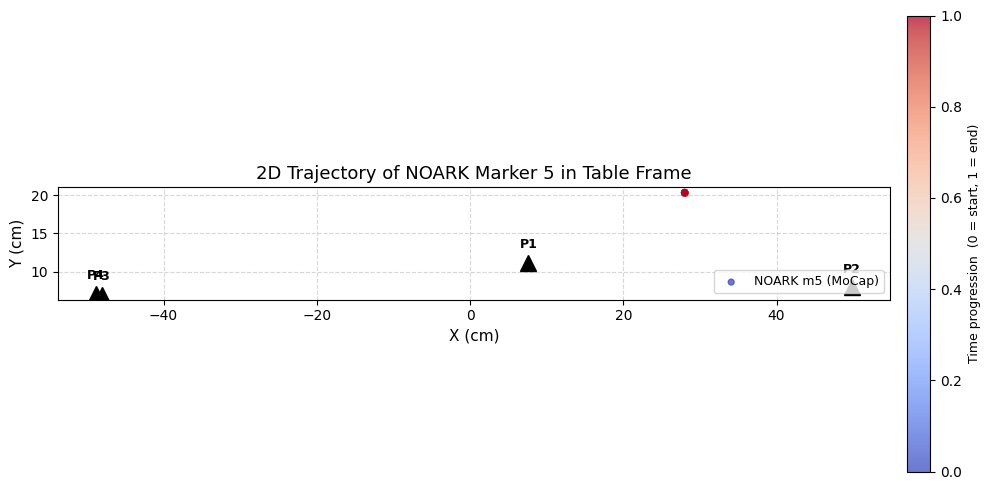


Trajectory extents:
  X : nan → nan cm  (range nan cm)
  Y : nan → nan cm  (range nan cm)
  N frames plotted: 136


In [20]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ── pull data ─────────────────────────────────────────────────────────────────
df_n = tframe_dfs['noark_in_tframe'].copy()
df_t = tframe_dfs['table_in_tframe'].copy()

# convert m → cm
x_cm = df_n['noark_m5_tf_x_m'].values * 100.0
y_cm = df_n['noark_m5_tf_y_m'].values * 100.0

# ── colour map: time progression ─────────────────────────────────────────────
t_norm = (np.arange(len(x_cm)) / max(len(x_cm) - 1, 1))   # 0 → 1

# ── table corner reference points (mean over all frames, m → cm) ─────────────
corner_labels = ['P1', 'P2', 'P3', 'P4']
corner_xy = []
for i in range(1, 5):
    cx = df_t[f'table_m{i}_tf_x_m'].mean() * 100.0
    cy = df_t[f'table_m{i}_tf_y_m'].mean() * 100.0
    corner_xy.append((cx, cy))

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sc = ax.scatter(
    x_cm, y_cm,
    c=t_norm,
    cmap='coolwarm',
    s=18,
    alpha=0.75,
    zorder=2,
    label='NOARK m5 (MoCap)',
)

# colourbar
cbar = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.03)
cbar.set_label('Time progression  (0 = start, 1 = end)', fontsize=9)

# table corner markers
for (cx, cy), lbl in zip(corner_xy, corner_labels):
    ax.plot(cx, cy, marker='^', markersize=12, color='black', zorder=5)
    ax.annotate(
        lbl,
        xy=(cx, cy),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold',
    )

ax.set_xlabel('X (cm)', fontsize=11)
ax.set_ylabel('Y (cm)', fontsize=11)
ax.set_title('2D Trajectory of NOARK Marker 5 in Table Frame', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f'\nTrajectory extents:')
print(f'  X : {x_cm.min():.1f} → {x_cm.max():.1f} cm  (range {x_cm.max()-x_cm.min():.1f} cm)')
print(f'  Y : {y_cm.min():.1f} → {y_cm.max():.1f} cm  (range {y_cm.max()-y_cm.min():.1f} cm)')
print(f'  N frames plotted: {len(x_cm)}')
